# Curso: Redes Neurais e Deep Learning

Prof. Denilson Alves Pereira 
https://sites.google.com/ufla.br/denilsonpereira/ 
Departamento de Ciência da Computação - 
Instituto de Ciências Exatas e Tecnológicas - 
Universidade Federal de Lavras

## Introdução ao Framework Keras

Objetivo: apresentar um exemplo de aplicação da rede neural usando a API Keras. Keras é uma biblioteca de código aberto para criação de redes neurais que roda sobre o TensorFlow, CNTK, ou Theano.

Documentação: https://keras.io/

Versão: Maio, 2021

## O Problema

Classificar dados de sinais coletados da ionosfera terrestre.

Entrada: instâncias compostas por 33 atributos representando os sinais coletados.

Saída: "G" (Good): o radar retorna que os elétrons livres na ionosfera mostram a evidência de algum tipo de estrutura; "B" (Bad): os elétrons livres não indicam estrutura.

## Arquitetura Inicial

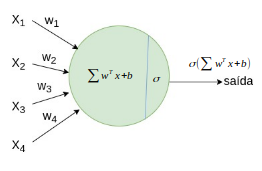

<p>
Será implementado um classificador binário usando a regressão logística (Logistic Regression Classifier) para resolver o problema.
    
**Expressões Matemáticas**:

Para um exemplo $x^{(i)}$:

$$
z^{(i)} = w^T x^{(i)} + b
$$

$$
\hat{y}^{(i)} = a^{(i)} = sigmoid(z^{(i)})
$$ 

$$
\mathcal{L}(a^{(i)}, y^{(i)}) =  - y^{(i)}  \log(a^{(i)}) - (1-y^{(i)} )  \log(1-a^{(i)})
$$

O custo é computado somando-se todos os exemplos de treino:
$$ J = \frac{1}{m} \sum_{i=1}^m \mathcal{L}(a^{(i)}, y^{(i)})$$

## Pacotes

In [1]:
!pip install numpy tensorflow pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 7.2 MB/s eta 0:00:000m eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 13.7 MB/s eta 0:00:0031m14.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 12.0 MB/s eta 0:00:0031m12.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.8 MB/s eta 0:00:0031m14.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 12.4 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.9/409.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [2]:
import numpy as np # package for scientific computing
import tensorflow as tf  #  package for numerical computation using data flow graphs
from tensorflow import keras  # package for deep learning
import pandas as pd # package for working with structured data

I0000 00:00:1788380848.028440  457378 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788380848.028955  457378 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788380848.062231  457378 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788380849.069131  457378 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## Dados para Treino e Teste

Fonte: https://www.kaggle.com/prashant111/ionosphere?select=ionosphere_data.csv

In [3]:
df = pd.read_csv('ionosphere_data.csv')
df['column_a'] = df.column_a.astype('float64') # convert boolean feature into numeric
df.drop(columns=['column_b'], inplace=True) # remove useless feature
df.head() # display dataset first lines


,column_a,column_c,column_d,column_e,column_f,column_g,column_h,column_i,column_j,column_k,...,column_z,column_aa,column_ab,column_ac,column_ad,column_ae,column_af,column_ag,column_ah,column_ai
0,1.0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,0.85243,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1.0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,0.50874,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1.0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,0.73082,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1.0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1.0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,0.52798,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


In [4]:
# Encoding the output class
df.rename(columns={'column_ai': 'label'}, inplace=True)
encoding = {'g': 1, 'b': 0}
df["label"] = df["label"].replace(encoding)
df["label"] = df["label"].astype("category")
df.head()

,column_a,column_c,column_d,column_e,column_f,column_g,column_h,column_i,column_j,column_k,...,column_z,column_aa,column_ab,column_ac,column_ad,column_ae,column_af,column_ag,column_ah,label
0,1.0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,0.85243,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,1
1,1.0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,0.50874,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,0
2,1.0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,0.73082,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,1
3,1.0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,0
4,1.0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,0.52798,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,1


Documentação de *train_test_split*: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html <br>
A função divide os dados em partições de treino e teste, de acordo com a proporção especificada pelo parâmetro *test_size*. <br>
O parâmetro *random_state* é usado para deixar os resultados reproduzíveis para fins de avaliação do exercício.

In [5]:
# Preparing the dataset for training and test
from sklearn.model_selection import train_test_split
X = df.values[:,:-1]
Y = df.values[:,-1]
train_set_X, test_set_X, train_set_Y, test_set_Y = train_test_split(X, Y, test_size=0.20, random_state=7)

Documentação de *fit_transform*: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html <br>
A função modifica o valor da cada atributo de cada instância dos dados com base na média e no desvio padrão do conjunto de dados.

In [6]:
# Standardize features by removing the mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# The boolean feature does not need to be normalized.
train_set_X[:,1:] = scaler.fit_transform(train_set_X[:,1:])
test_set_X[:,1:]  = scaler.fit_transform(test_set_X[:,1:])

### Atenção
No formato da entrada de dados da API Keras, as linhas representam as instâncias (exemplos) e as colunas representam os atributos. Isso é invertido em relação ao que foi visto até agora na implementação mostrada nos exemplos anteriores.

In [7]:
n = train_set_X.shape[1] # number of attributes
m = train_set_X.shape[0] # number of training examples

print ("Number of attributes: n = " + str(n))
print ("Number of training examples: m = " + str(m))
print ("Train set X shape: " + str(train_set_X.shape))
print ("Train set Y shape: " + str(train_set_Y.shape))
print ("Test set X shape: " + str(test_set_X.shape))
print ("Test set Y shape: " + str(test_set_Y.shape))

Number of attributes: n = 33
Number of training examples: m = 280
Train set X shape: (280, 33)
Train set Y shape: (280,)
Test set X shape: (71, 33)
Test set Y shape: (71,)


## Definição do Modelo

O modelo em Keras é definido como uma sequência de camadas.

No exemplo abaixo, a rede é constituida de apenas um neurônio, o qual recebe os dados da camada de entrada e produz a saída. Como é um problema de classificação binária, a saída é produzida pela função de ativação Sigmóide.

Documentações: <br>
Classe *Model*: https://keras.io/api/models/model/ <br>
Funções de ativação disponíveis: https://keras.io/api/layers/activations/ 

In [8]:
inputs = keras.Input(shape=(train_set_X.shape[1],))  # the shape of inputs (number of attributes)
outputs = keras.layers.Dense(units=1, activation="sigmoid")(inputs)  # single neuron network with sigmoid as activation function
model = keras.Model(inputs=inputs, outputs=outputs)  # instantiate a Model object

E0000 00:00:1788380850.460082  457378 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1788380850.460899  459080 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1788380850.477985  457378 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [9]:
# Checking
processed_data = model(train_set_X)
print(processed_data.shape)

(280, 1)


In [10]:
# Prints a summary of the network, showing its architecture and parameters.
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 33)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34 (136.00 B)

 Trainable params: 34 (136.00 B)

 Non-trainable params: 0 (0.00 B)

## Compilação do Modelo

Na compilação do modelo, a biblioteca de backend (TensorFlow, por exemplo) escolhe a melhor forma de representar a rede no seu hardware, tal como CPU, GPU ou TPU.

Os seguintes parâmetros devem ser especificados:
1. Loss Function – função de perda. No exemplo, será utilizada a função Cross-Entropy, usada na Regressão Logística.
2. Optimizer – otimizador, o qual executa o algoritmo da descida do gradiente. Um otimizador popular é chamado de "adam".
3. Metrics – métricas a serem monitoradas (opcional)

Documentação: https://keras.io/api/models/model_training_apis/

In [11]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

## Treinamento do Modelo

Ajusta o modelo aos dados de treinamento.
Devem ser fornecidos os dados de treinamento, o número de épocas (iterações) e o tamanho do lote (batch). Uma época é composta por uma única passagem por todos os exemplos do conjunto de treino. O tamanho do lote define o número de amostras (exemplos) a serem consideradas pelo modelo antes de atualizar os pesos. Assim, uma época é composta por um ou mais lotes.

Documentação: https://keras.io/api/models/model_training_apis/

In [12]:
history = model.fit(train_set_X, train_set_Y, batch_size=32, epochs=100)  # history records what happened over the course of training
print(history.history)  # print per-epoch timeseries of metrics values

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7357 - loss: 0.6029  
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7464 - loss: 0.5891 
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7571 - loss: 0.5752 
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7786 - loss: 0.5628 
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7857 - loss: 0.5513 
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8036 - loss: 0.5406 
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8250 - loss: 0.5298 
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8321 - loss: 0.5199 
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8286 - loss: 0.5111 
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8321 - loss: 0.5021 
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8321 - loss: 0.4945 
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8321 - lo

## Avaliação do Modelo

Avalia o desempenho da rede no conjunto de teste.

Documentação: https://keras.io/api/models/model_training_apis/

In [13]:
loss, acc = model.evaluate(test_set_X, test_set_Y)
print("loss: %.2f" % loss)
print("acc: %.2f" % acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8873 - loss: 0.3623 
loss: 0.36
acc: 0.89


## Predição

Prediz a saída de novos dados.

Documentação: https://keras.io/api/models/model_training_apis/

In [14]:
predictions = model.predict(test_set_X)
print("Predictions: ", [round(x[0]) for x in predictions])
print("\nCorrect:     ", [round(x) for x in test_set_Y])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Predictions:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1]

Correct:      [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1]


# Fim

Esses foram os passos para criação de uma rede neural simples, composta de um único neurônio.

Com o incremento do número de camadas, a rede é capaz de aprender atributos mais complexos.
A seguir, vamos criar uma rede neural com mais camadas e aplicá-la para resolver o mesmo problema de classificação anterior.

-------------------------------------------

# Nova Arquitetura

Vamos criar agora um novo modelo, seguindo a arquitetura abaixo:

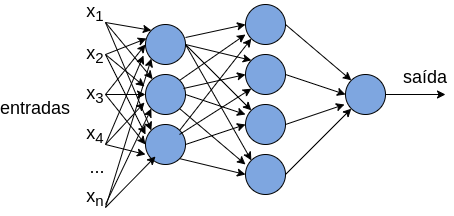

**Medindo o tamanho de uma rede:**
As duas métricas mais comumente usadas são o número de neurônios e o número de parâmetros (mais comum). A rede acima, considerando 33 atributos de entrada, tem:
- 3 + 4 + 1 = 8 neurônios (não contando as entradas) e
- (33 x 3) + (3 x 4) + (4 x 1) = 115 pesos e 3 + 4 + 1 = 8 biases, totalizando 123 parâmetros a serem aprendidos.

## Definição do Modelo em Keras

In [15]:
inputs = keras.Input(shape=(train_set_X.shape[1],))  # the shape of inputs (number of attributes)
x = keras.layers.Dense(units=3, activation="relu")(inputs)  ## first layer, 3 neurons, activation function ReLu
x = keras.layers.Dense(units=4, activation="relu")(x)  ## second layer, 4 neurons, activation function ReLu
outputs = keras.layers.Dense(units=1, activation="sigmoid")(x)  # output layer, 1 neuron, activation function Sigmoid
model = keras.Model(inputs=inputs, outputs=outputs)  # instantiate a Model object

In [16]:
# Prints a summary of the network, showing its architecture and parameters.
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 33)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           102 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123 (492.00 B)

 Trainable params: 123 (492.00 B)

 Non-trainable params: 0 (0.00 B)

## Compilação do Modelo

In [17]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

## Treinamento do Modelo

In [18]:
history = model.fit(train_set_X, train_set_Y, batch_size=32, epochs=100)  # history records what happened over the course of training
print(history.history)  # print per-epoch timeseries of metrics values

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6321 - loss: 0.6879  
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6321 - loss: 0.6819 
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6321 - loss: 0.6767 
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6321 - loss: 0.6710 
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6321 - loss: 0.6659 
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6321 - loss: 0.6610 
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6321 - loss: 0.6552 
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6321 - loss: 0.6500 
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6321 - loss: 0.6445 
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6321 - loss: 0.6394 
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6321 - loss: 0.6340 
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6321 - lo

## Avaliação do Modelo

In [19]:
loss, acc = model.evaluate(test_set_X, test_set_Y)
print("loss: %.2f" % loss)
print("acc: %.2f" % acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8732 - loss: 0.4321 
loss: 0.43
acc: 0.87


## Predição

In [20]:
predictions = model.predict(test_set_X)
print("Predictions: ", [round(x[0]) for x in predictions])
print("\nCorrect:     ", [round(x) for x in test_set_Y])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Predictions:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1]

Correct:      [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1]
